<a href="https://colab.research.google.com/github/Ariqueeezz/Data-Mining-Project/blob/main/Proyek_Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Libraries***

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
# Clustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from yellowbrick.cluster import KElbowVisualizer
# Save Model
import joblib

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install kmedoids

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 2.5 MB/s eta 0:00:00


In [3]:
import kmedoids

# ***Load Data***

In [4]:
path='/content/drive/MyDrive/dataset/Dataset Data Mining Cleaned.xlsx'
df = pd.read_excel(path)
df.head()

,MITRA CHANNEL,Trx FY25-A,GTV FY25-A,GR FY25-A,NR FY25-A
0,Bank Mandiri,9774585,5.288021e+12,5.200642e+10,5.183290e+10
1,BRI,13569368,2.429050e+12,1.411133e+10,1.382592e+10
2,BCA,20897307,1.467878e+12,1.030808e+10,1.030807e+10
3,Acquirer Finnet,31461876,2.753419e+12,9.082905e+09,7.752868e+09
4,BNI,5319097,1.659882e+12,3.804040e+09,3.675951e+09


In [5]:
df.dtypes

,0
MITRA CHANNEL,object
Trx FY25-A,int64
GTV FY25-A,float64
GR FY25-A,float64
NR FY25-A,float64


# ***Data Cleaning & Transformation***



In [6]:
df['GTV FY25-A'] = df['GTV FY25-A'].astype('int')
df['GR FY25-A'] = df['GR FY25-A'].astype('int')
df['NR FY25-A'] = df['NR FY25-A'].astype('int')

In [7]:
df['Margin Profit (%)'] = np.where(
    df['GTV FY25-A'] != 0,
    (df['NR FY25-A'] / df['GTV FY25-A']) * 100,
    0
)

In [8]:
df.head()

,MITRA CHANNEL,Trx FY25-A,GTV FY25-A,GR FY25-A,NR FY25-A,Margin Profit (%)
0,Bank Mandiri,9774585,5288021409055,52006416773,51832900167,0.980195
1,BRI,13569368,2429049954649,14111331140,13825919170,0.569190
2,BCA,20897307,1467877504314,10308081812,10308074604,0.702244
3,Acquirer Finnet,31461876,2753418998885,9082904761,7752867902,0.281572
4,BNI,5319097,1659881551499,3804040280,3675950915,0.221459


In [9]:
numerical_df = df.select_dtypes(include=['int', 'float'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(numerical_df)

# Convert the scaled array back to a DataFrame for easier handling if needed
df_scaled = pd.DataFrame(df_scaled, columns=numerical_df.columns)
display(df_scaled.head())

,Trx FY25-A,GTV FY25-A,GR FY25-A,NR FY25-A,Margin Profit (%)
0,2.680036,8.457902,11.174935,11.178806,1.206830
1,3.793567,3.731693,2.922304,2.884860,0.577892
2,5.943856,2.142764,2.094049,2.117191,0.781496
3,9.043894,4.267912,1.827235,1.559589,0.137766
4,1.372630,2.460169,0.677626,0.669918,0.045777


# ***Clustering***

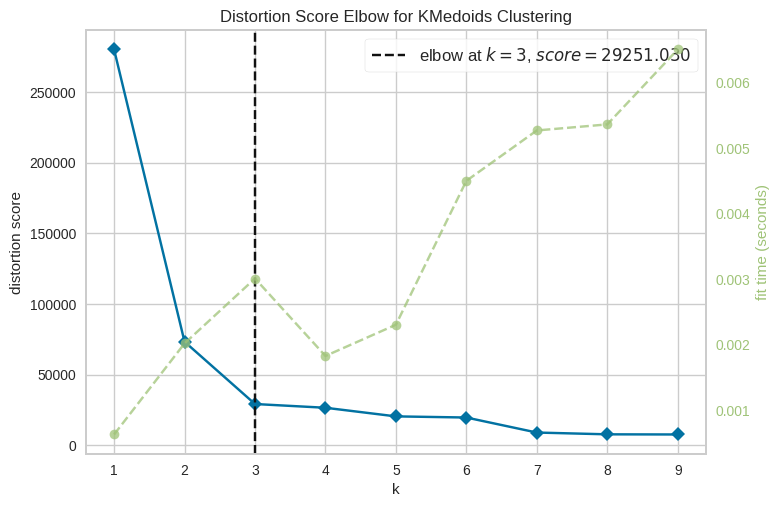

<Axes: title={'center': 'Distortion Score Elbow for KMedoids Clustering'}, xlabel='k', ylabel='distortion score'>

In [41]:
dist_matrix = pairwise_distances(df_scaled, metric='manhattan')

model = kmedoids.KMedoids(n_clusters=3, random_state=42, method='pam')

visualizer = KElbowVisualizer(model, k=(1, 10))
visualizer.fit(dist_matrix)
visualizer.show()

In [42]:
kmedoid = kmedoids.KMedoids(n_clusters=3, random_state=42, method='pam')
df['Cluster'] = kmedoid.fit_predict(dist_matrix)

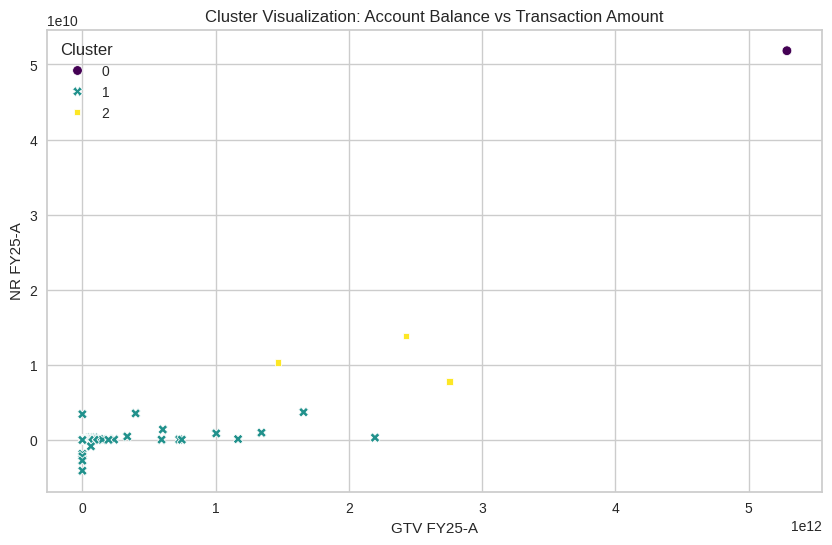

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GTV FY25-A', y='NR FY25-A', hue='Cluster', palette='viridis', style='Cluster')
plt.title('Cluster Visualization: Account Balance vs Transaction Amount')
plt.show()

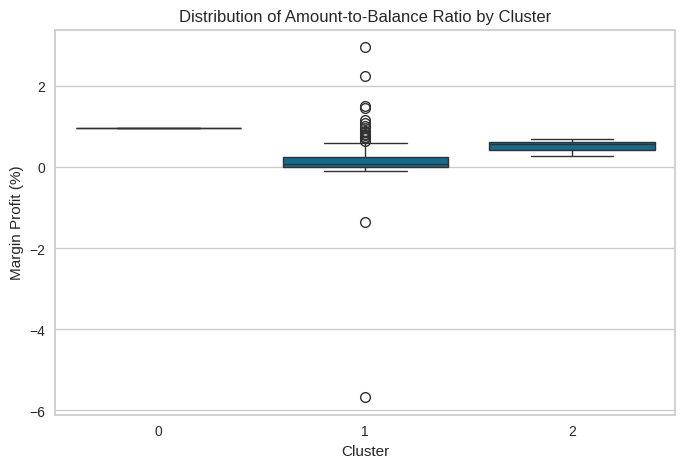

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster', y='Margin Profit (%)', data=df)
plt.title('Distribution of Amount-to-Balance Ratio by Cluster')
plt.show()

In [45]:
summary = df.groupby('Cluster')[['Trx FY25-A', 'GTV FY25-A', 'GR FY25-A', 'NR FY25-A', 'Margin Profit (%)']].mean()
summary['Trx FY25-A'] = summary['Trx FY25-A'].astype('int')
summary['GTV FY25-A'] = summary['GTV FY25-A'].astype('int')
summary['GR FY25-A'] = summary['GR FY25-A'].astype('int')
summary['NR FY25-A'] = summary['GR FY25-A'].astype('int')

summary

,Trx FY25-A,GTV FY25-A,GR FY25-A,NR FY25-A,Margin Profit (%)
Cluster,,,,,
0,9774585,5288021409055,52006416773,52006416773,0.980195
1,126276,92442767291,109795074,109795074,0.179100
2,21976183,2216782152616,11167439237,11167439237,0.517669


In [47]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,1
1,142
2,3


In [46]:
silhouette_score(dist_matrix, df['Cluster'])

np.float64(0.9182665666029589)

## **Interpretasi Cluster**

1. **Cluster 0** (Mitra Skala Raksasa / Volume & GTV Terbesar)
    - **Volume Transaksi (Trx)**: Paling Tinggi (~21,98 Juta transaksi)
    - **Gross Transaction Value (GTV)**: Sangat Besar / Raksasa (~Rp 2,21 Triliun)
    - **Net Revenue (NR)**: Paling Tinggi (~Rp 11,17 Miliar)
    - **Margin Profit (%)**: Menengah (~0,52%)
    - **Jumlah Anggota**: 3 Mitra
    
    Analisis: Cluster ini diisi oleh **3 mitra korporat raksasa** penggerak utama perputaran uang di platform, terlihat dari total GTV yang menyentuh angka Triliunan rupiah dan jumlah transaksi puluhan juta. Kontribusi pendapatan bersih (NR) mereka secara nominal adalah yang terbesar, meskipun persentase margin profitnya berada di angka moderat (0,52%)—kemungkinan besar karena adanya skema *pricing* khusus atau diskon korporat (*volume-based pricing*). Performa kelompok ini sangat krusial dipantau demi stabilitas arus kas bisnis.

2. **Cluster 1** (Mitra Skala Kecil / Mass Market)
    - **Volume Transaksi (Trx)**: Rendah (~126 Ribu transaksi)
    - **Gross Transaction Value (GTV)**: Rendah (~Rp 924,42 Juta)
    - **Net Revenue (NR)**: Rendah (~Rp 10,98 Juta)
    - **Margin Profit (%)**: Paling Rendah (~0,18%)
    - **Jumlah Anggota**: 142 Mitra
    
    Analisis: Cluster ini merupakan kelompok **mayoritas mitra** (142 dari 146 mitra). Perilaku bisnisnya menunjukkan skala yang masih kecil dengan nilai transaksi di bawah 1 Miliar rupiah serta kontribusi margin yang tipis. Mitra di kelompok ini kemungkinan besar adalah pelaku usaha mikro/kecil yang membutuhkan program inkubasi atau promosi khusus agar volume dan nilai transaksinya bisa naik kelas.


3. **Cluster 2** (Mitra Skala Besar / Profitabilitas Tinggi)
    - **Volume Transaksi (Trx)**: Tinggi (~9,77 Juta transaksi)
    - **Gross Transaction Value (GTV)**: Tinggi (~Rp 52,88 Miliar)
    - **Net Revenue (NR)**: Tinggi (~Rp 5,20 Miliar)
    - **Margin Profit (%)**: Paling Tinggi (~0,98%)
    - **Jumlah Anggota**: 1 Mitra
    
    Analisis: Cluster ini berisi **satu mitra jangkar (anchor tenant)** yang sangat berharga. Meskipun skala bisnisnya (GTV) tidak sebesar Cluster 2, mitra ini menyumbang margin profit tertinggi (~0,98%) dengan efisiensi pendapatan bersih (NR) yang sangat luar biasa. Ini adalah tipe mitra ideal yang menghasilkan profitabilitas maksimal bagi platform.

In [35]:
target_mapping = {
    0 : "Skala Rakasasa",
    1 : "Skala Kecil",
    2 : "Skala Besar"
}
df['Cluster'] = df['Cluster'].map(target_mapping)

In [36]:
df.shape

(146, 7)

In [37]:
df.head()

,MITRA CHANNEL,Trx FY25-A,GTV FY25-A,GR FY25-A,NR FY25-A,Margin Profit (%),Cluster
0,Bank Mandiri,9774585,5288021409055,52006416773,51832900167,0.980195,Skala Rakasasa
1,BRI,13569368,2429049954649,14111331140,13825919170,0.569190,Skala Besar
2,BCA,20897307,1467877504314,10308081812,10308074604,0.702244,Skala Besar
3,Acquirer Finnet,31461876,2753418998885,9082904761,7752867902,0.281572,Skala Besar
4,BNI,5319097,1659881551499,3804040280,3675950915,0.221459,Skala Kecil


## **Model Testing**

In [38]:
joblib.dump(kmedoid, 'model_clustering.joblib')

['model_clustering.joblib']